# Seed Sweep Analysis: ifBO Candidate Selection vs. Random Search

Analyzes every `sample-results/seeded/<variant>-seed<seed>.jsonl` file
(produced by `scripts/run_seed_sweep.py`, mirrored from
`seeded_runs_results/<dataset>/*/history.log.jsonl`). The variants and
seeds analyzed below are **discovered dynamically** from whatever files
exist in that folder when this notebook runs -- drop a new
`<variant>-seed<seed>.jsonl` file into `sample-results/seeded/` and rerun,
no code changes needed. The "Discovered variants & seeds" printout below
the next cell is the live inventory for this run.

Variant keys seen so far map to:

- **ifBO (greedy)** (`ifbo-greedy`) — `ifbo_use_random_selection=False`,
  `ifbo_greedy_candidate_selection=True`. The acquisition function always
  proposes the candidate the FT-PFN surrogate ranks best.
- **ifBO (random selection)** (`ifbo-random`) —
  `ifbo_use_random_selection=True`. An ablation: candidates are drawn
  uniformly at random instead of by acquisition ranking (see
  `automl/core/optimizers/ifbo/optimizer.py`'s `_select_next_candidate`).
- **Random search** (`random`) — the `random` optimizer baseline (no
  multi-fidelity; every trial trains for the full epoch budget).

Any other variant key gets a generic prettified label and the next unused
color from a fallback palette -- see `_prettify`/`_COLOR_OVERRIDES` below.
Not every variant necessarily has a run for every seed; per-seed panels
simply skip a (variant, seed) combination with no file, and the paired
ifBO comparison further down only uses seeds common to both ifBO variants.

Each file is a `history.log.jsonl`-style trial log: one JSON object per
completed trial with its sampled `config`, `budget` (epochs trained),
`val_error`, `timestamp`, and per-epoch `epoch_history`.


In [1]:
import json
import math
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

RESULTS_DIR = Path("seeded")


def parse_stem(stem: str) -> tuple[str, int]:
    """Split e.g. 'ifbo-random-seed238' into ('ifbo-random', 238)."""
    variant_key, sep, seed_str = stem.rpartition("-seed")
    if not sep or not seed_str.isdigit():
        raise ValueError(f"Could not parse variant/seed from stem {stem!r}")
    return variant_key, int(seed_str)


# Nicer labels/colors for the variants we know about; anything new dropped
# into RESULTS_DIR still gets picked up automatically via the fallbacks.
_LABEL_OVERRIDES = {
    "ifbo-greedy": "ifBO (greedy)",
    "ifbo-random": "ifBO (random selection)",
    "random": "Random search",
}
_COLOR_OVERRIDES = {
    "ifbo-greedy": "#2a78d6",  # blue
    "ifbo-random": "#eda100",  # yellow
    "random": "#1aad10",  # green
}
_FALLBACK_PALETTE = ["#c0392b", "#8e44ad", "#16a085", "#7f8c8d", "#d35400", "#2c3e50"]


def _prettify(variant_key: str) -> str:
    if variant_key in _LABEL_OVERRIDES:
        return _LABEL_OVERRIDES[variant_key]
    words = variant_key.split("-")
    return " ".join("ifBO" if w.lower() == "ifbo" else w.capitalize() for w in words)


# Discover every (variant, seed) pair actually present in seeded/.
FILES = sorted(RESULTS_DIR.glob("*.jsonl"))
PARSED_FILES = [(*parse_stem(p.stem), p) for p in FILES]

VARIANT_KEYS = sorted({variant_key for variant_key, _, _ in PARSED_FILES})
SEEDS = sorted({seed for _, seed, _ in PARSED_FILES})
VARIANTS = {k: _prettify(k) for k in VARIANT_KEYS}

_fallback_iter = iter(_FALLBACK_PALETTE)
COLORS = {k: _COLOR_OVERRIDES.get(k, next(_fallback_iter, "#999999")) for k in VARIANT_KEYS}

GRID_NCOLS = 3
GRID_NROWS = math.ceil(len(SEEDS) / GRID_NCOLS)


def seed_grid(**subplots_kwargs):
    fig, axes = plt.subplots(GRID_NROWS, GRID_NCOLS, **subplots_kwargs)
    axes_flat = np.atleast_1d(axes).flatten()
    for ax in axes_flat[len(SEEDS) :]:
        ax.set_visible(False)
    return fig, axes_flat[: len(SEEDS)]


print(f"Discovered {len(FILES)} files -> {len(VARIANT_KEYS)} variant(s) x up to {len(SEEDS)} seed(s)")
for k, label in VARIANTS.items():
    seeds_for_k = sorted(seed for vk, seed, _ in PARSED_FILES if vk == k)
    print(f"  {label!r:28s} ({k}): {len(seeds_for_k)} seed(s) -- {seeds_for_k}")


Discovered 31 files -> 3 variant(s) x up to 13 seed(s)
  'ifBO (greedy)'              (ifbo-greedy): 13 seed(s) -- [0, 1, 2, 3, 4, 5, 6, 12, 24, 36, 78, 90, 238]
  'ifBO (random selection)'    (ifbo-random): 13 seed(s) -- [0, 1, 2, 3, 4, 5, 6, 12, 24, 36, 78, 90, 238]
  'Random search'              (random): 5 seed(s) -- [1, 2, 12, 24, 36]


## Load trial histories

Every `ifbo-random-seed*.jsonl` file contains each `trialNo` **twice**: the
sweep's `python -m automl` process was invoked a second time for that
(variant, seed) cell, re-sampling the identical trial sequence (same
optimizer seed => same RNG draws) on top of the first run's config
checkpoints. Most of the second pass's `execution_time` values are ~0s
(instant checkpoint-cache hits, per `train_single_configuration` in
`automl/core/optimizers/base_optimizer.py`), confirming it's a redundant
replay rather than new search progress -- so we keep only the
chronologically first occurrence of each `trialNo` below. This does not
affect `ifbo-greedy-seed*.jsonl`, which has no duplicate `trialNo`s.


In [2]:
TIMESTAMP_FMT = "%Y%m%d_%H%M%S,%f"


def load_trials(path: Path) -> list[dict]:
    trials = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                trials.append(json.loads(line))
    return trials


raw_trials: dict[tuple[str, int], list[dict]] = {}
rows = []

for variant_key, seed, path in PARSED_FILES:
    trials = load_trials(path)
    trials.sort(key=lambda t: datetime.strptime(t["timestamp"], TIMESTAMP_FMT))

    n_raw = len(trials)
    seen_trial_nos: set[int] = set()
    deduped = []
    for t in trials:
        if t["trialNo"] not in seen_trial_nos:
            seen_trial_nos.add(t["trialNo"])
            deduped.append(t)
    trials = deduped
    if n_raw != len(trials):
        print(f"{path.name}: dropped {n_raw - len(trials)} duplicate-trialNo replay rows")

    raw_trials[(variant_key, seed)] = trials

    t0 = datetime.strptime(trials[0]["timestamp"], TIMESTAMP_FMT)
    running_best = float("inf")
    for t in trials:
        ts = datetime.strptime(t["timestamp"], TIMESTAMP_FMT)
        running_best = min(running_best, t["val_error"])
        rows.append(
            {
                "variant": variant_key,
                "seed": seed,
                "trialNo": t["trialNo"],
                "budget": t["budget"],
                "execution_time": t["execution_time"],
                "wallclock_s": (ts - t0).total_seconds(),
                "val_error": t["val_error"],
                "val_accuracy": 1.0 - t["val_error"],
                "best_val_accuracy_so_far": 1.0 - running_best,
            }
        )

trials_df = pd.DataFrame(rows)
trials_df["variant_label"] = trials_df["variant"].map(VARIANTS)
trials_df.head()


ifbo-random-seed12.jsonl: dropped 15 duplicate-trialNo replay rows
ifbo-random-seed238.jsonl: dropped 15 duplicate-trialNo replay rows
ifbo-random-seed24.jsonl: dropped 15 duplicate-trialNo replay rows
ifbo-random-seed36.jsonl: dropped 15 duplicate-trialNo replay rows
ifbo-random-seed78.jsonl: dropped 15 duplicate-trialNo replay rows
ifbo-random-seed90.jsonl: dropped 15 duplicate-trialNo replay rows


,variant,seed,trialNo,budget,execution_time,wallclock_s,val_error,val_accuracy,best_val_accuracy_so_far,variant_label
0,ifbo-greedy,0,1,3.0,223.313816,0.000000,0.1916,0.8084,0.8084,ifBO (greedy)
1,ifbo-greedy,0,2,3.0,593.170164,594.717860,0.5000,0.5000,0.8084,ifBO (greedy)
2,ifbo-greedy,0,3,3.0,120.947919,719.431571,0.2272,0.7728,0.8084,ifBO (greedy)
3,ifbo-greedy,0,4,4.0,78.574954,799.454305,0.1856,0.8144,0.8144,ifBO (greedy)
4,ifbo-greedy,0,5,3.0,46.555725,850.489614,0.5000,0.5000,0.8144,ifBO (greedy)


## 1. Best validation accuracy vs. trial number, per seed

Faint dots are individual trials; the step line is the running best-so-far
incumbent within that seed's run. ifBO (greedy) was configured for 20
trials and ifBO (random selection) for 15 in this sweep, so the greedy
lines extend further right.


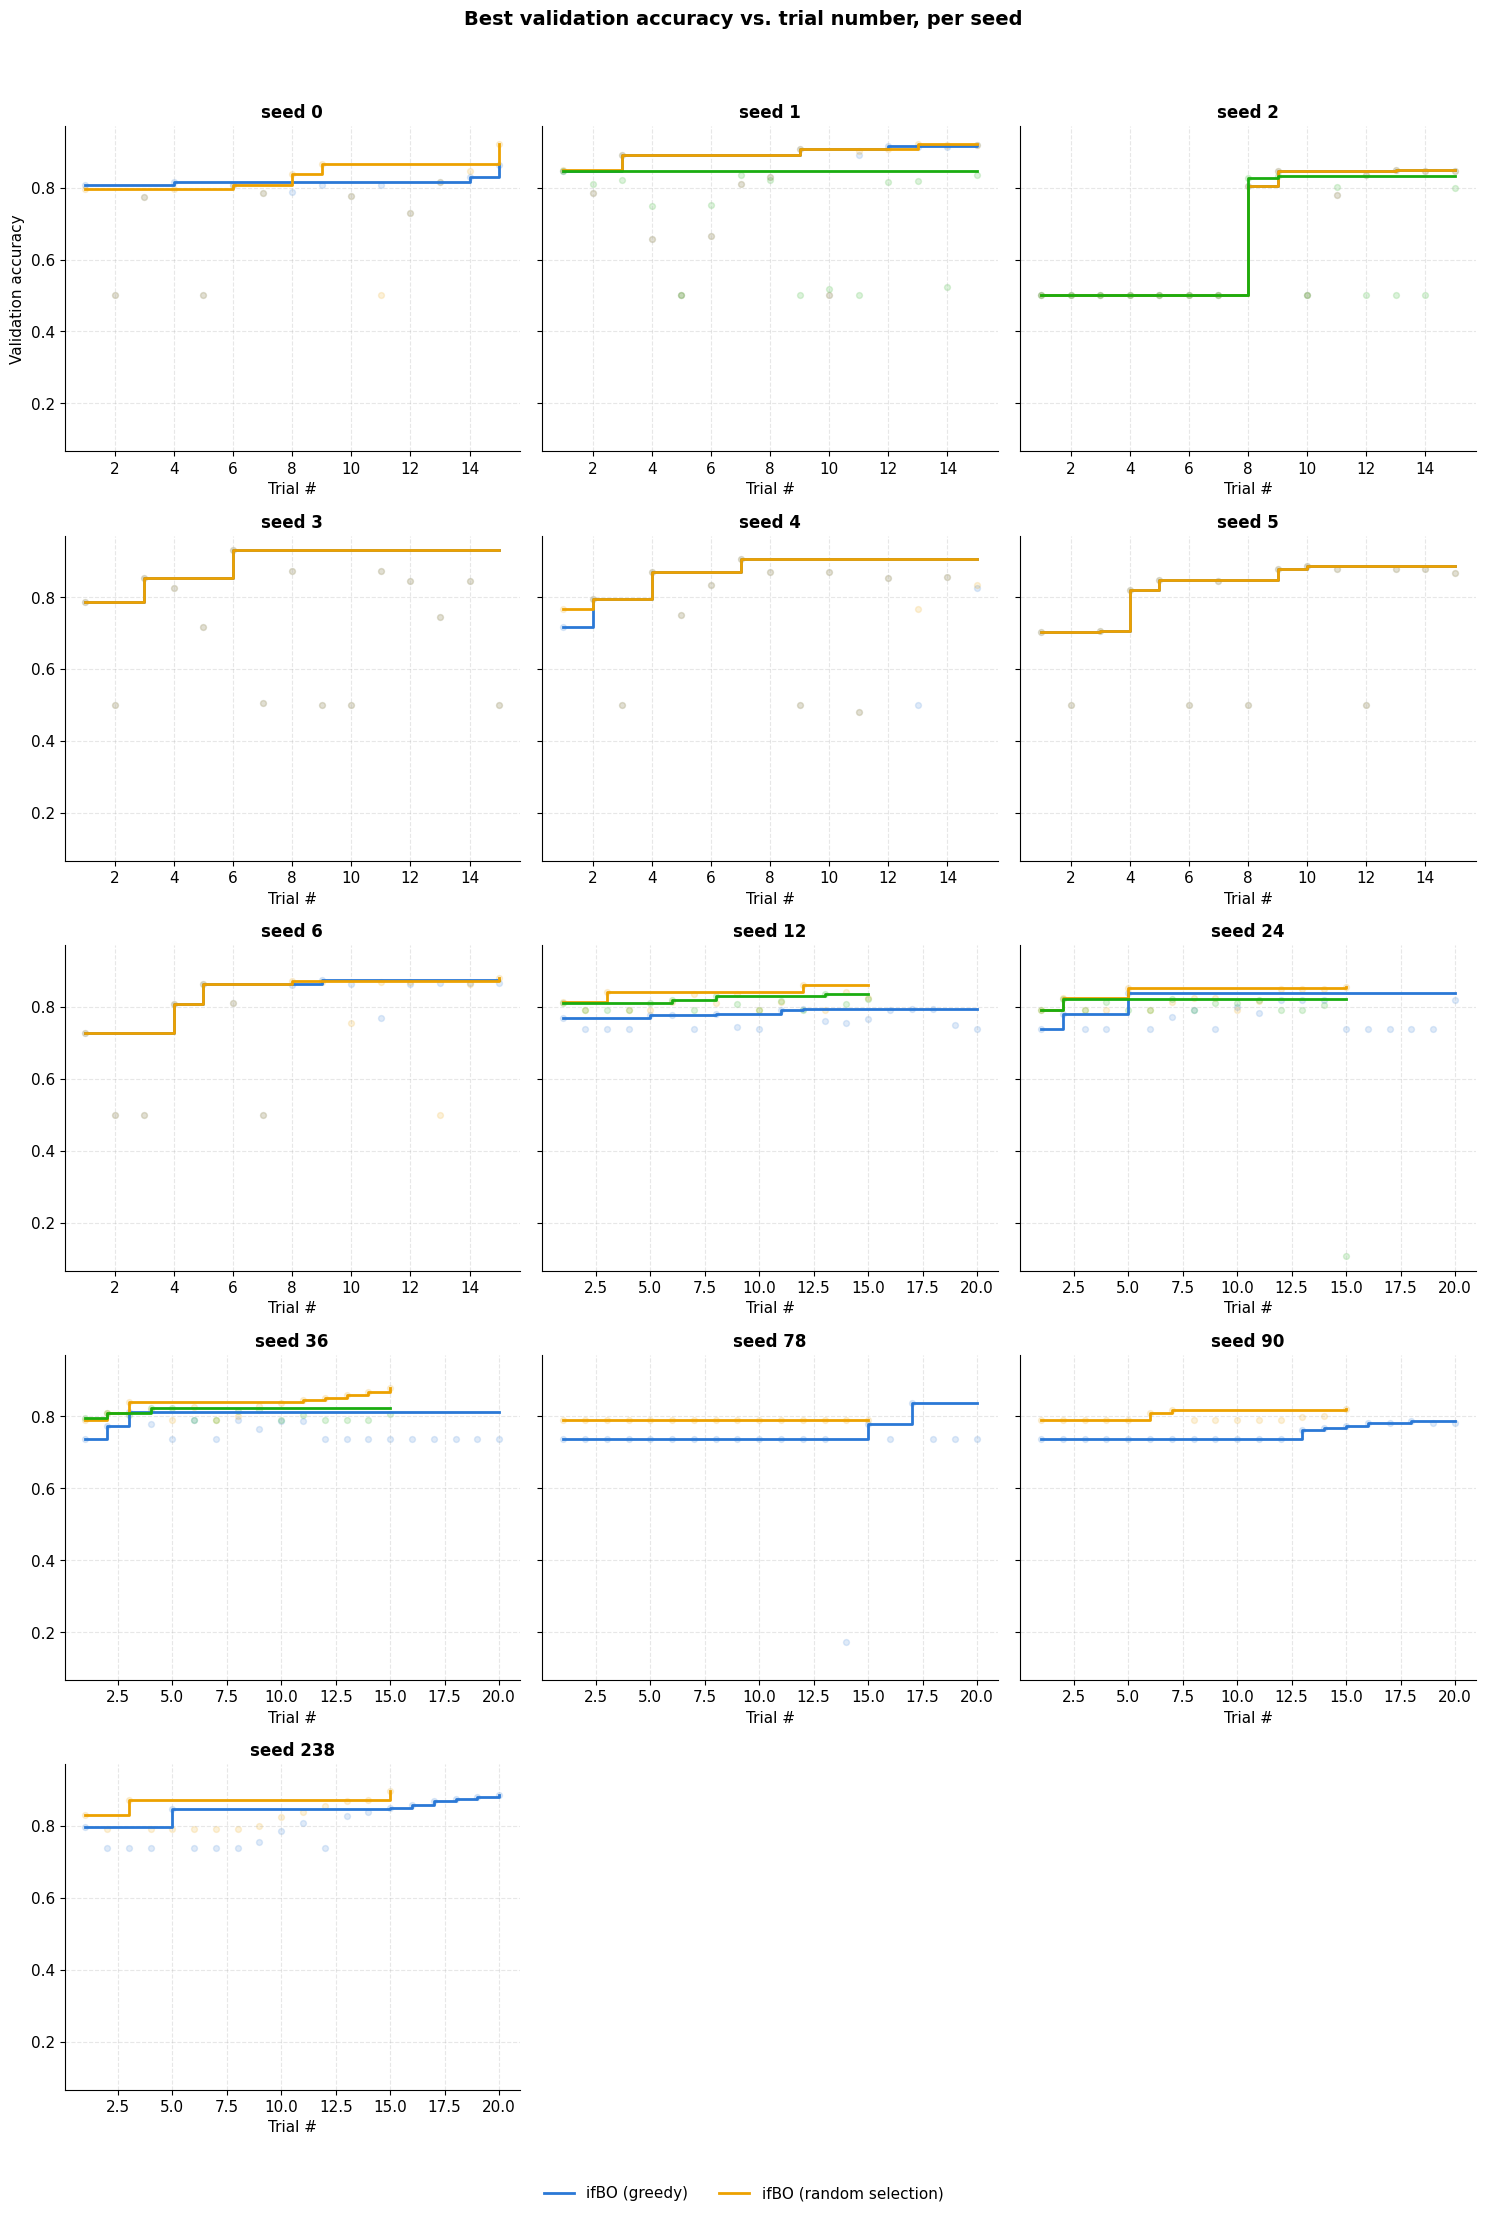

In [3]:
fig, axes = seed_grid(figsize=(5 * GRID_NCOLS, 4.2 * GRID_NROWS), sharey=True)
for ax, seed in zip(axes, SEEDS):
    sub_seed = trials_df[trials_df["seed"] == seed]
    for variant_key, variant_label in VARIANTS.items():
        sub = sub_seed[sub_seed["variant"] == variant_key].sort_values("trialNo")
        if sub.empty:
            continue
        color = COLORS[variant_key]
        ax.scatter(
            sub["trialNo"], sub["val_accuracy"], color=color, alpha=0.15, s=18, zorder=1
        )
        ax.step(
            sub["trialNo"],
            sub["best_val_accuracy_so_far"],
            where="post",
            color=color,
            linewidth=2.0,
            label=variant_label,
            zorder=2,
        )
    ax.set_title(f"seed {seed}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Trial #")

axes[0].set_ylabel("Validation accuracy")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.03), frameon=False)
fig.suptitle("Best validation accuracy vs. trial number, per seed", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


## 2. Best validation accuracy vs. wallclock time, per seed

Same per-seed view as above, but the x-axis is actual search wallclock
time rather than trial count. Since a trial's duration depends on the
epoch budget it trained for (see section 9), a variant that runs cheaper
trials can look better here even if it needs more trials to get there.


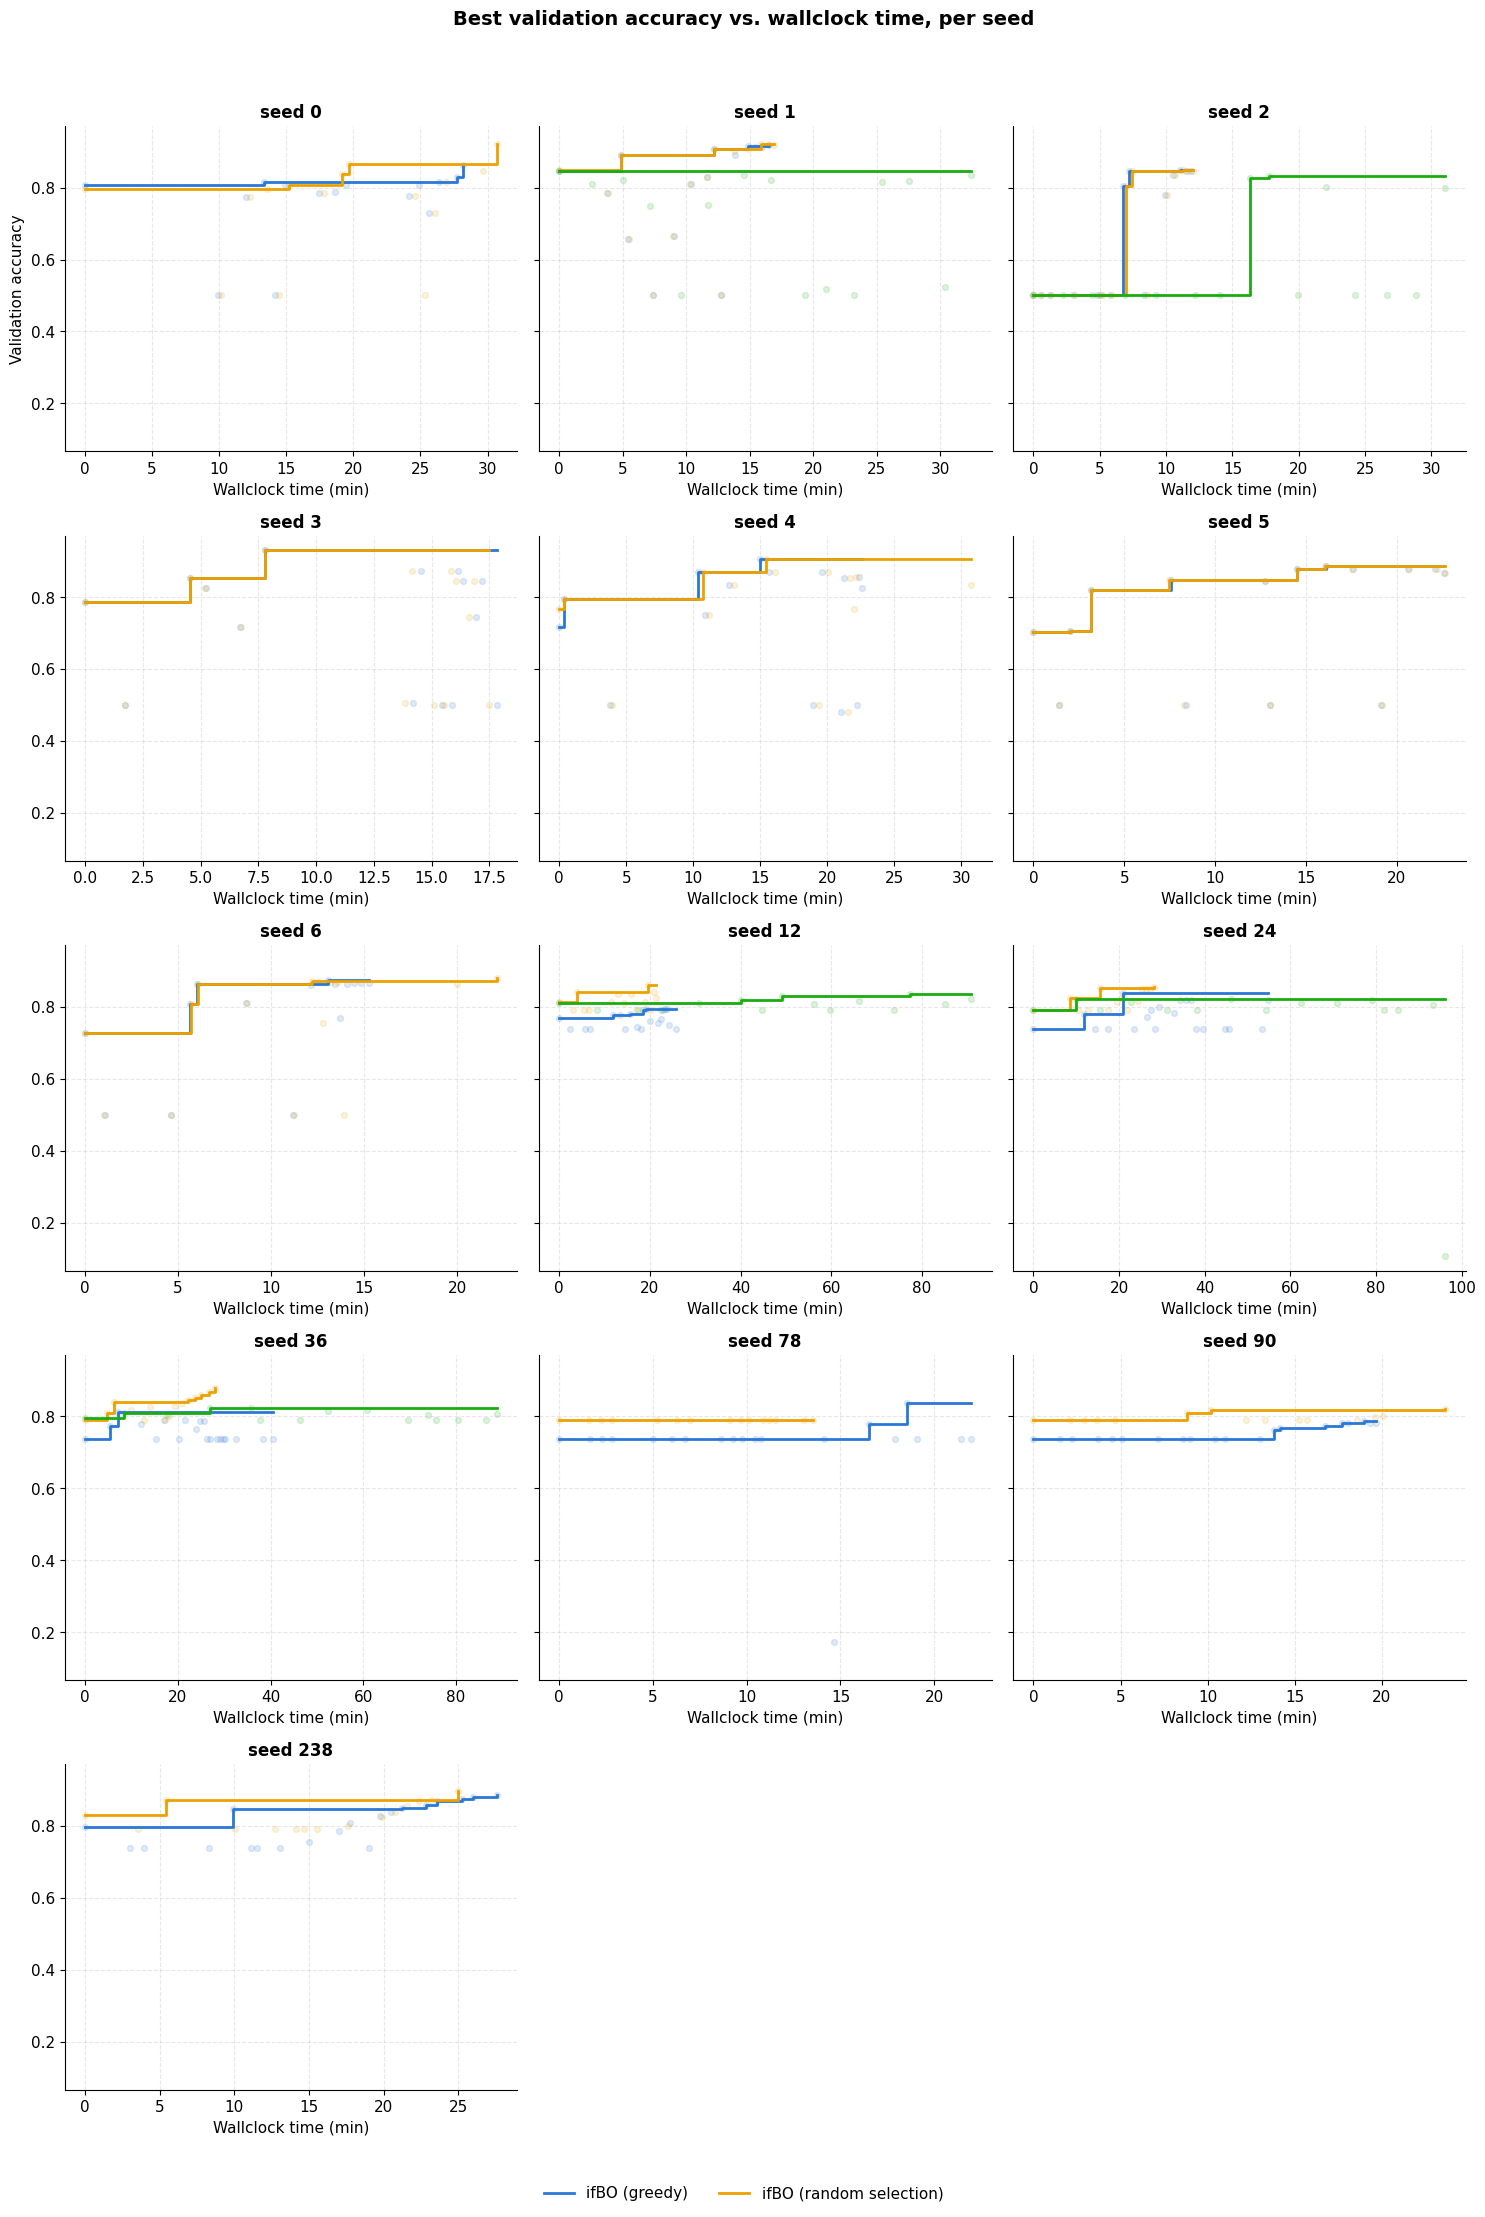

In [4]:
fig, axes = seed_grid(figsize=(5 * GRID_NCOLS, 4.2 * GRID_NROWS), sharey=True)
for ax, seed in zip(axes, SEEDS):
    sub_seed = trials_df[trials_df["seed"] == seed]
    for variant_key, variant_label in VARIANTS.items():
        sub = sub_seed[sub_seed["variant"] == variant_key].sort_values("wallclock_s")
        if sub.empty:
            continue
        color = COLORS[variant_key]
        x_min = sub["wallclock_s"] / 60.0
        ax.scatter(x_min, sub["val_accuracy"], color=color, alpha=0.15, s=18, zorder=1)
        ax.step(
            x_min,
            sub["best_val_accuracy_so_far"],
            where="post",
            color=color,
            linewidth=2.0,
            label=variant_label,
            zorder=2,
        )
    ax.set_title(f"seed {seed}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Wallclock time (min)")

axes[0].set_ylabel("Validation accuracy")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.03), frameon=False)
fig.suptitle("Best validation accuracy vs. wallclock time, per seed", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


## 3. Aggregated convergence across seeds — trial number

Mean best-so-far validation accuracy at each trial number, averaged over
the seeds available for each variant, with a ±1 std-dev band. This is the
main seed-sweep readout: it isolates the *systematic* effect of the
candidate selection rule from per-seed noise. Bands narrow where more
seeds agree and widen as runs branch out or as fewer seeds remain to
average over (variants aren't required to share the same seed set).


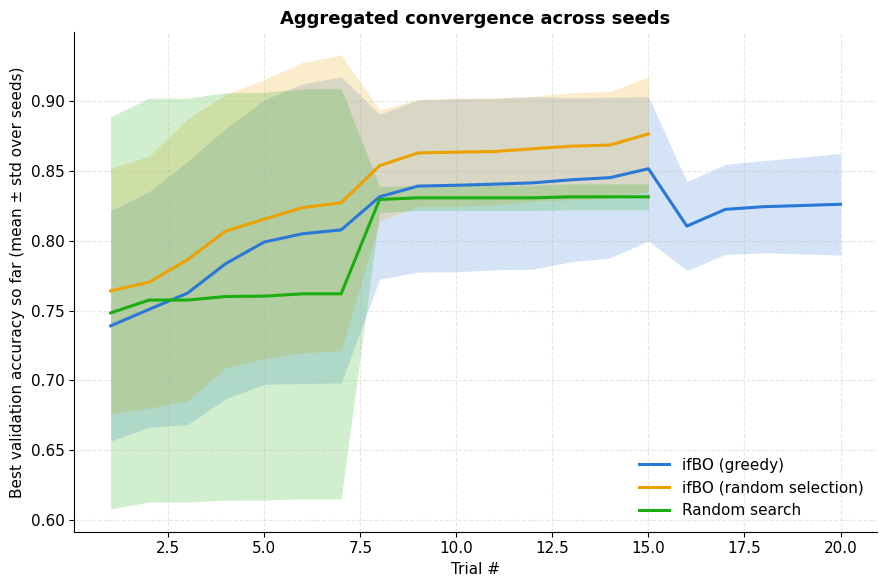

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
for variant_key, variant_label in VARIANTS.items():
    sub = trials_df[trials_df["variant"] == variant_key]
    agg = sub.groupby("trialNo")["best_val_accuracy_so_far"].agg(["mean", "std", "count"])
    color = COLORS[variant_key]
    ax.plot(agg.index, agg["mean"], color=color, linewidth=2.2, label=variant_label)
    ax.fill_between(
        agg.index,
        agg["mean"] - agg["std"],
        agg["mean"] + agg["std"],
        color=color,
        alpha=0.2,
        linewidth=0,
    )

ax.set_xlabel("Trial #")
ax.set_ylabel("Best validation accuracy so far (mean ± std over seeds)")
ax.set_title("Aggregated convergence across seeds", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
plt.show()


## 4. Aggregated convergence across seeds — wallclock time

Same idea as the trial-number aggregation above, but each seed's
best-so-far step function is resampled onto a common wallclock-time grid
first (holding a seed's incumbent constant once its search finishes),
then averaged. This is the fairest read of "how good is the incumbent
after N minutes of search," since it accounts for trials not all costing
the same amount of wallclock time.


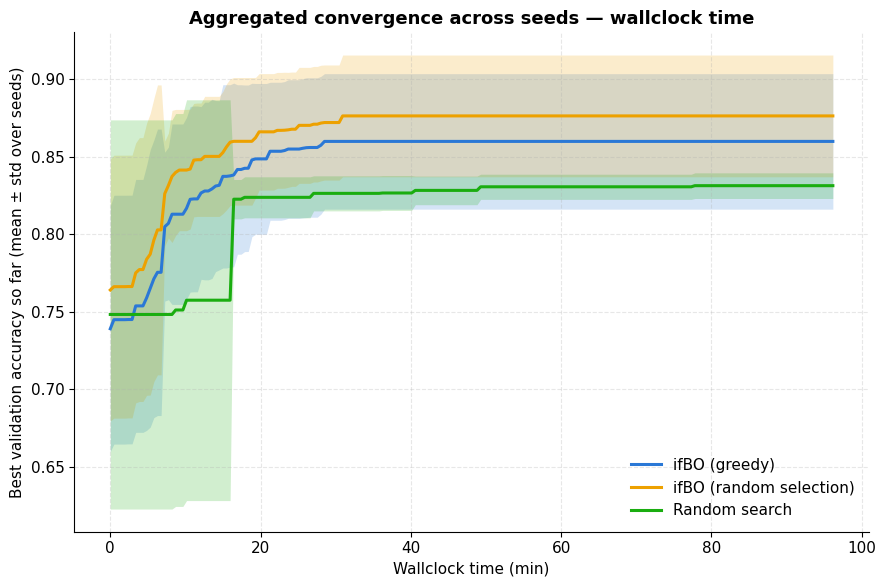

In [6]:
def best_so_far_at(seed: int, variant_key: str, t_grid: np.ndarray) -> np.ndarray:
    sub = trials_df[(trials_df["seed"] == seed) & (trials_df["variant"] == variant_key)].sort_values("wallclock_s")
    times = sub["wallclock_s"].to_numpy()
    values = sub["best_val_accuracy_so_far"].to_numpy()
    idx = np.searchsorted(times, t_grid, side="right") - 1
    result = np.full_like(t_grid, np.nan, dtype=float)
    valid = idx >= 0
    result[valid] = values[idx[valid]]
    return result


max_t = trials_df["wallclock_s"].max()
t_grid = np.linspace(0, max_t, 200)

fig, ax = plt.subplots(figsize=(9, 6))
for variant_key, variant_label in VARIANTS.items():
    curves = np.stack([best_so_far_at(seed, variant_key, t_grid) for seed in SEEDS])
    mean = np.nanmean(curves, axis=0)
    std = np.nanstd(curves, axis=0)
    color = COLORS[variant_key]
    ax.plot(t_grid / 60.0, mean, color=color, linewidth=2.2, label=variant_label)
    ax.fill_between(t_grid / 60.0, mean - std, mean + std, color=color, alpha=0.2, linewidth=0)

ax.set_xlabel("Wallclock time (min)")
ax.set_ylabel("Best validation accuracy so far (mean ± std over seeds)")
ax.set_title("Aggregated convergence across seeds — wallclock time", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
plt.show()


## 5. Final best accuracy per seed


In [7]:
final_acc = (
    trials_df.groupby(["seed", "variant"])["val_accuracy"]
    .max()
    .unstack("variant")[list(VARIANTS)]
)
final_acc.columns = final_acc.columns.map(VARIANTS)
final_acc


variant,ifBO (greedy),ifBO (random selection),Random search
seed,,,
0,0.8616,0.921200,NaN
1,0.9180,0.920000,0.844800
2,0.8480,0.848000,0.832000
3,0.9300,0.930000,NaN
4,0.9052,0.906000,NaN
5,0.8856,0.885600,NaN
6,0.8748,0.879200,NaN
12,0.7950,0.860744,0.834734
24,0.8390,0.855942,0.821929


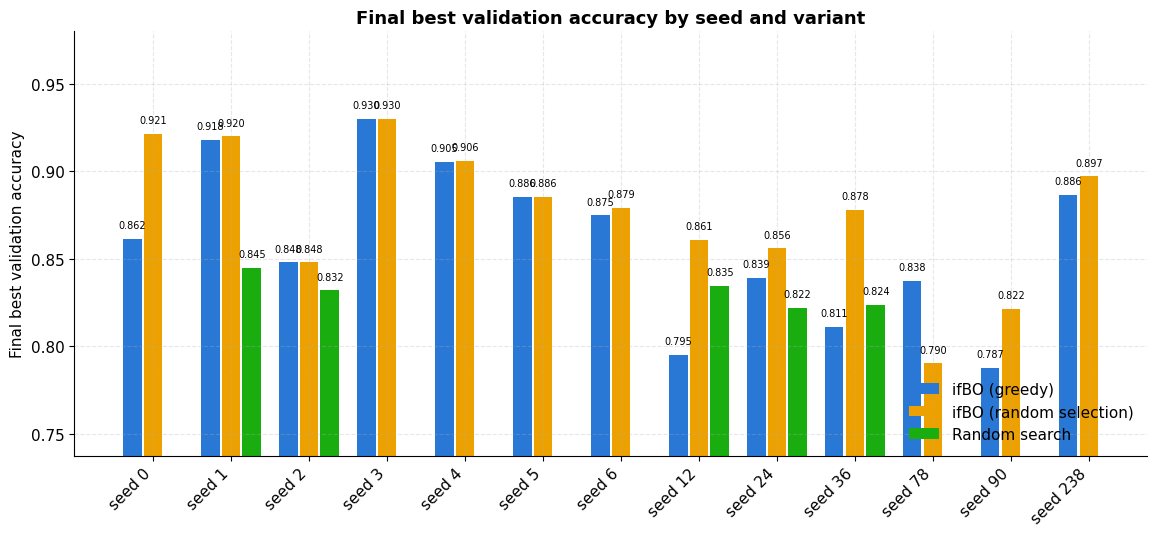

In [8]:
fig, ax = plt.subplots(figsize=(max(9, 0.9 * len(final_acc.index)), 5.5))
n_var = len(VARIANTS)
x = np.arange(len(final_acc.index))
width = 0.8 / n_var

for i, (variant_key, variant_label) in enumerate(VARIANTS.items()):
    vals = final_acc[variant_label]
    offset = x + i * width - 0.4 + width / 2
    ax.bar(offset, vals, width=width * 0.9, color=COLORS[variant_key], label=variant_label)
    for xi, v in zip(offset, vals):
        if pd.isna(v):
            continue
        ax.text(xi, v + 0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([f"seed {s}" for s in final_acc.index], rotation=45, ha="right")
ax.set_ylabel("Final best validation accuracy")
ax.set_ylim(np.nanmin(final_acc.values) - 0.05, np.nanmax(final_acc.values) + 0.05)
ax.set_title("Final best validation accuracy by seed and variant", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
plt.show()


## 6. Robustness across seeds

Distribution of each variant's *final* best accuracy across the 6 seeds.
A tighter, higher distribution means the candidate-selection rule finds a
strong incumbent reliably regardless of seed, not just on lucky draws.


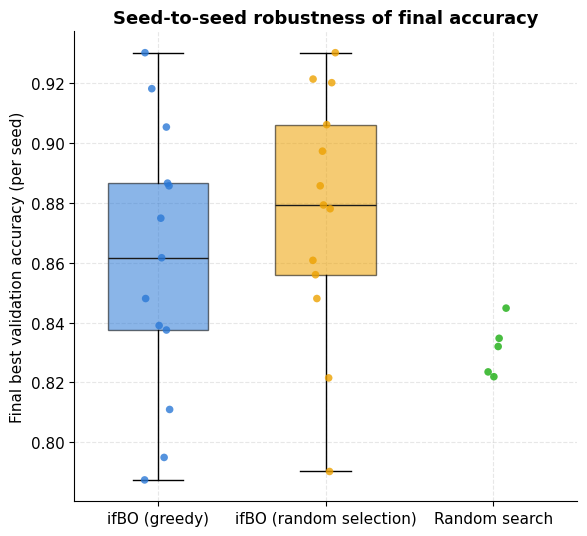

variant,ifBO (greedy),ifBO (random selection),Random search
mean,0.859977,0.876434,0.831398
std,0.045515,0.040901,0.009256
min,0.787500,0.790316,0.821929
max,0.930000,0.930000,0.844800


In [9]:
fig, ax = plt.subplots(figsize=(6, 5.5))
rng = np.random.default_rng(0)
data = [final_acc[variant_label].values for variant_label in VARIANTS.values()]

bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=False)
for patch, variant_key in zip(bp["boxes"], VARIANTS):
    patch.set_facecolor(COLORS[variant_key])
    patch.set_alpha(0.55)
for median in bp["medians"]:
    median.set_color("#1a1a19")

for i, variant_label in enumerate(VARIANTS.values(), start=1):
    pts = final_acc[variant_label].values
    jitter = rng.uniform(-0.08, 0.08, size=len(pts))
    ax.scatter(
        np.full(len(pts), i) + jitter, pts, color=COLORS[list(VARIANTS)[i - 1]],
        s=30, alpha=0.8, zorder=3, edgecolor="none",
    )

ax.set_xticks(range(1, len(VARIANTS) + 1))
ax.set_xticklabels(list(VARIANTS.values()))
ax.set_ylabel("Final best validation accuracy (per seed)")
ax.set_title("Seed-to-seed robustness of final accuracy", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

final_acc.agg(["mean", "std", "min", "max"]).rename(columns=lambda c: c)


## 7. Paired per-seed comparison: ifBO greedy vs. random selection

ifBO (greedy) and ifBO (random selection) share a set of seeds, so we can
pair them up directly: each line below connects one seed's greedy result
to its random-selection result on that *same* seed. A Wilcoxon
signed-rank test on the paired differences checks whether greedy's edge
(or lack of one) is more than noise -- treat the p-value as indicative,
not conclusive, given how few paired seeds are typically available. This
comparison is specific to the two ifBO ablation arms; a plain random-search
baseline, if present, isn't part of this pairing since it isn't guaranteed
to share the same seeds.


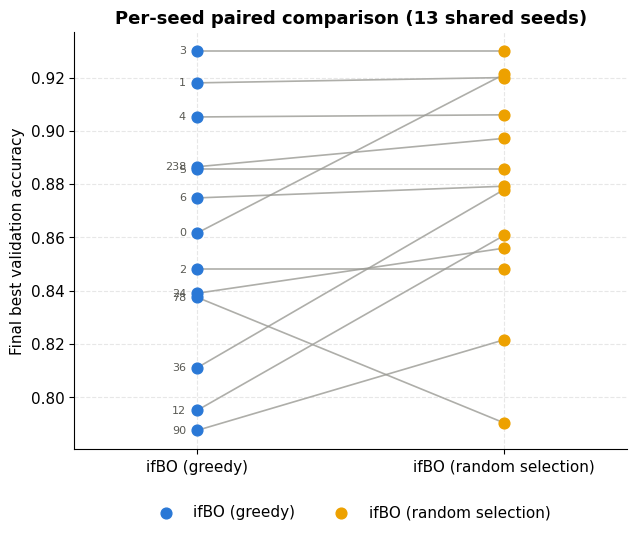

Mean (greedy - random) final accuracy: -0.0165 (std 0.0325)
Seeds where greedy wins: 1/13
Wilcoxon signed-rank test: statistic=7.00, p=0.0371


In [10]:
if "ifbo-greedy" in VARIANTS and "ifbo-random" in VARIANTS:
    greedy_label, random_label = VARIANTS["ifbo-greedy"], VARIANTS["ifbo-random"]
    paired = final_acc[[greedy_label, random_label]].dropna()

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    for seed, row in paired.iterrows():
        ax.plot(
            [0, 1], [row[greedy_label], row[random_label]],
            color="#9a9a94", linewidth=1.2, zorder=1, alpha=0.8,
        )
        ax.annotate(f"{seed}", (0, row[greedy_label]), textcoords="offset points",
                    xytext=(-8, 0), ha="right", va="center", fontsize=8, color="#5a5a54")

    ax.scatter(np.zeros(len(paired)), paired[greedy_label], color=COLORS["ifbo-greedy"], s=60, zorder=2, label=greedy_label)
    ax.scatter(np.ones(len(paired)), paired[random_label], color=COLORS["ifbo-random"], s=60, zorder=2, label=random_label)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([greedy_label, random_label])
    ax.set_xlim(-0.4, 1.4)
    ax.set_ylabel("Final best validation accuracy")
    ax.set_title(f"Per-seed paired comparison ({len(paired)} shared seeds)", fontsize=13, fontweight="bold")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
    fig.tight_layout()
    plt.show()

    diff = paired[greedy_label] - paired[random_label]
    wilcoxon_res = stats.wilcoxon(paired[greedy_label], paired[random_label])
    print(f"Mean (greedy - random) final accuracy: {diff.mean():+.4f} (std {diff.std():.4f})")
    print(f"Seeds where greedy wins: {(diff > 0).sum()}/{len(diff)}")
    print(f"Wilcoxon signed-rank test: statistic={wilcoxon_res.statistic:.2f}, p={wilcoxon_res.pvalue:.4f}")
else:
    print("Skipping paired ifBO greedy-vs-random comparison: one of the two variants is not present in sample-results/seeded/.")


## 8. Search cost: trials run and wallclock time

Variants (and even different seeds of the same variant) can be configured
with different trial budgets per sweep cell -- see the table below -- so
raw wallclock time isn't always directly comparable across variants.
Shown here for completeness alongside trial counts, not as a head-to-head
speed comparison.


In [11]:
cost = trials_df.groupby(["seed", "variant"]).agg(
    n_trials=("trialNo", "max"), total_wallclock_min=("wallclock_s", "max")
)
cost["total_wallclock_min"] /= 60.0
cost = cost.unstack("variant")
cost.columns = cost.columns.set_levels(cost.columns.levels[1].map(VARIANTS), level=1)
cost


n_trials                                        \
variant ifBO (greedy) ifBO (random selection) Random search   
seed                                                          
0                15.0                    15.0           NaN   
1                15.0                    15.0          15.0   
2                15.0                    15.0          15.0   
3                15.0                    15.0           NaN   
4                15.0                    15.0           NaN   
5                15.0                    15.0           NaN   
6                15.0                    15.0           NaN   
12               20.0                    15.0          15.0   
24               20.0                    15.0          15.0   
36               20.0                    15.0          15.0   
78               20.0                    15.0           NaN   
90               20.0                    15.0           NaN   
238              20.0                    15.0           NaN   

        total_wallclock_min                                        
variant       ifBO (greedy) ifBO (random selection) Random search  
seed                                                               
0                 28.201581               30.689863           NaN  
1                 16.486899               16.917417     32.411639  
2                 11.885501               12.047510     31.031760  
3                 17.818836               17.479655           NaN  
4                 22.625130               30.737932           NaN  
5                 22.587681               22.664559           NaN  
6                 15.247085               22.130745           NaN  
12                25.844246               21.384732     90.860790  
24                54.707247               28.256751     96.166486  
36                40.478962               27.951862     88.789553  
78                21.962930               13.529790           NaN  
90                19.675774               23.634004           NaN  
238               27.580976               25.003983           NaN

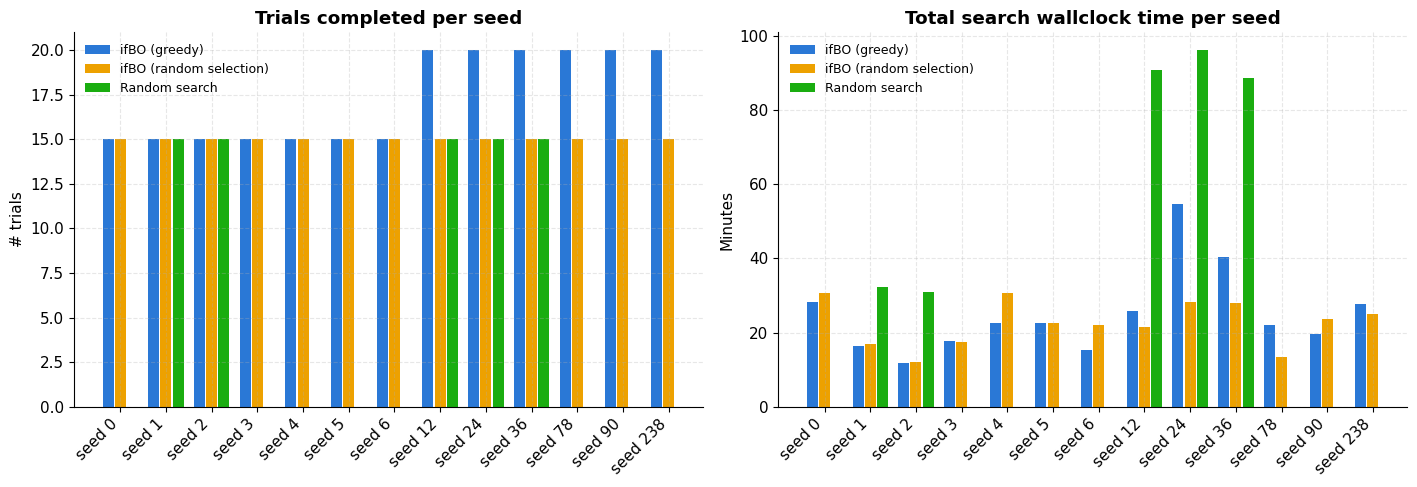

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(max(13, 1.1 * len(SEEDS)), 5))
x = np.arange(len(SEEDS))
width = 0.8 / len(VARIANTS)

for i, (variant_key, variant_label) in enumerate(VARIANTS.items()):
    offset = x + i * width - 0.4 + width / 2
    n_trials = cost[("n_trials", variant_label)]
    wallclock = cost[("total_wallclock_min", variant_label)]
    axes[0].bar(offset, n_trials, width=width * 0.9, color=COLORS[variant_key], label=variant_label)
    axes[1].bar(offset, wallclock, width=width * 0.9, color=COLORS[variant_key], label=variant_label)

axes[0].set_title("Trials completed per seed", fontweight="bold")
axes[0].set_ylabel("# trials")
axes[1].set_title("Total search wallclock time per seed", fontweight="bold")
axes[1].set_ylabel("Minutes")
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels([f"seed {s}" for s in SEEDS], rotation=45, ha="right")
    ax.legend(loc="upper left", frameon=False, fontsize=9)
fig.tight_layout()
plt.show()


## 9. Per-trial execution time: cost of an evaluation

All seeds pooled. Left: distribution of how long a single trial takes to
train, per variant. Right: trial cost vs. the epoch budget it trained for
-- since ifBO's freeze-thaw can resume a config from a prior checkpoint,
cost tracks the *incremental* epochs trained rather than the cumulative
budget shown on the x-axis, so expect a loose, not perfectly linear,
relationship.


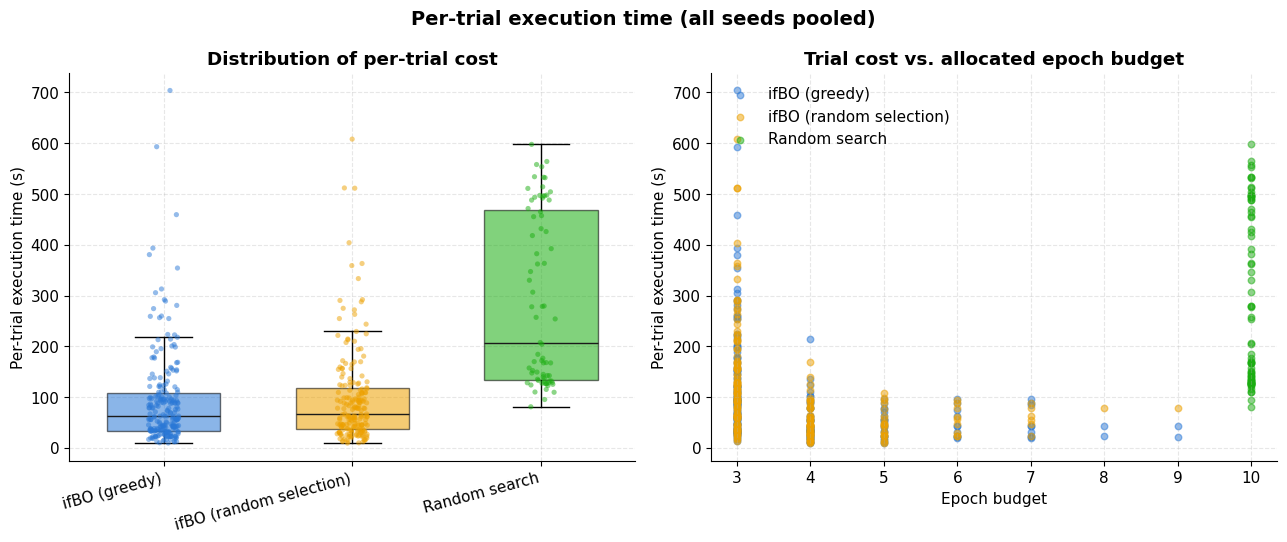

,mean,50%,std,max
variant_label,,,,
Random search,288.962482,207.374991,166.273206,597.795230
ifBO (greedy),92.380006,62.361179,93.921712,703.975101
ifBO (random selection),97.196421,66.821524,93.678205,608.121260


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
rng = np.random.default_rng(0)

data = [trials_df[trials_df["variant"] == v]["execution_time"].to_numpy() for v in VARIANTS]
bp = axes[0].boxplot(data, patch_artist=True, widths=0.6, showfliers=False)
for patch, variant_key in zip(bp["boxes"], VARIANTS):
    patch.set_facecolor(COLORS[variant_key])
    patch.set_alpha(0.55)
for median in bp["medians"]:
    median.set_color("#1a1a19")

for i, variant_key in enumerate(VARIANTS, start=1):
    pts = trials_df[trials_df["variant"] == variant_key]["execution_time"].to_numpy()
    jitter = rng.uniform(-0.08, 0.08, size=len(pts))
    axes[0].scatter(
        np.full(len(pts), i) + jitter, pts, color=COLORS[variant_key], s=14, alpha=0.5, zorder=3, edgecolor="none"
    )

axes[0].set_xticks(range(1, len(VARIANTS) + 1))
axes[0].set_xticklabels(list(VARIANTS.values()), rotation=15, ha="right")
axes[0].set_ylabel("Per-trial execution time (s)")
axes[0].set_title("Distribution of per-trial cost", fontweight="bold")

for variant_key, variant_label in VARIANTS.items():
    sub = trials_df[trials_df["variant"] == variant_key]
    axes[1].scatter(sub["budget"], sub["execution_time"], color=COLORS[variant_key], alpha=0.5, s=22, label=variant_label)

axes[1].set_xlabel("Epoch budget")
axes[1].set_ylabel("Per-trial execution time (s)")
axes[1].set_title("Trial cost vs. allocated epoch budget", fontweight="bold")
axes[1].legend(loc="upper left", frameon=False)

fig.suptitle("Per-trial execution time (all seeds pooled)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

trials_df.groupby("variant_label")["execution_time"].describe()[["mean", "50%", "std", "max"]]


## 10. Fidelity (epoch budget) allocated per trial

Shows each variant's freeze-thaw behavior: how many epochs get allocated
to each successive trial as the search progresses.


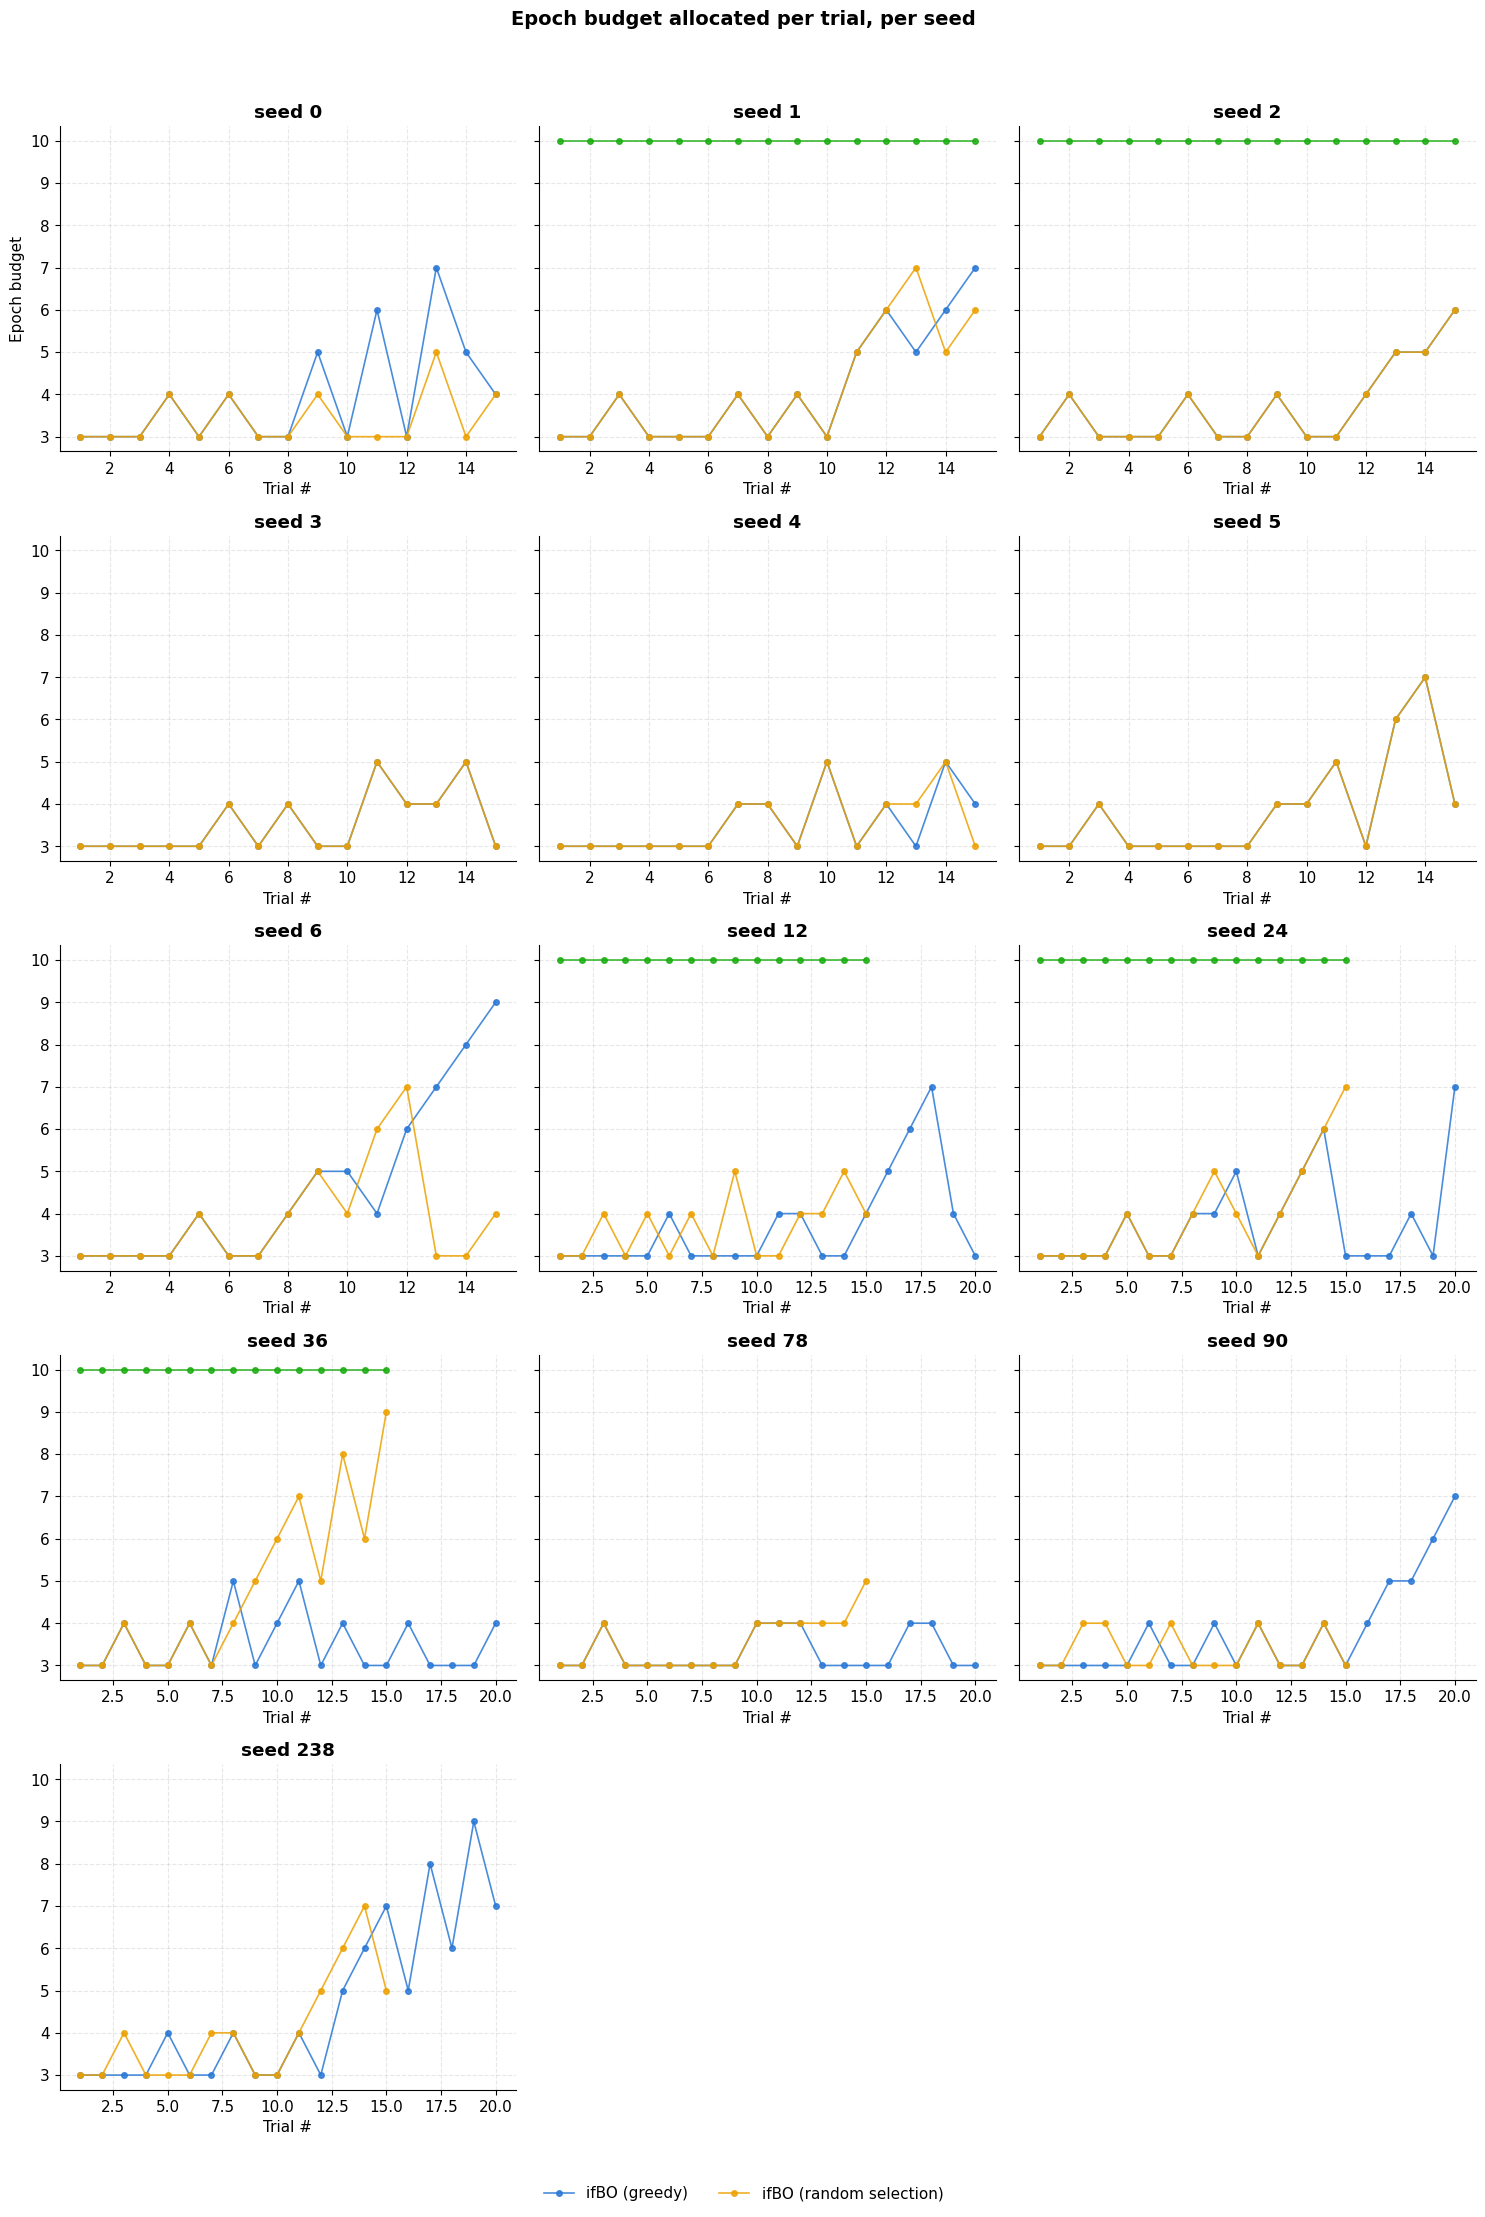

In [14]:
fig, axes = seed_grid(figsize=(5 * GRID_NCOLS, 4.2 * GRID_NROWS), sharey=True)
for ax, seed in zip(axes, SEEDS):
    sub_seed = trials_df[trials_df["seed"] == seed]
    for variant_key, variant_label in VARIANTS.items():
        sub = sub_seed[sub_seed["variant"] == variant_key].sort_values("trialNo")
        if sub.empty:
            continue
        ax.plot(
            sub["trialNo"], sub["budget"], "o-", color=COLORS[variant_key],
            markersize=4, linewidth=1.2, alpha=0.85, label=variant_label,
        )
    ax.set_title(f"seed {seed}", fontweight="bold")
    ax.set_xlabel("Trial #")

axes[0].set_ylabel("Epoch budget")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.03), frameon=False)
fig.suptitle("Epoch budget allocated per trial, per seed", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


## 11. Training curve of each variant's best trial (across all seeds)


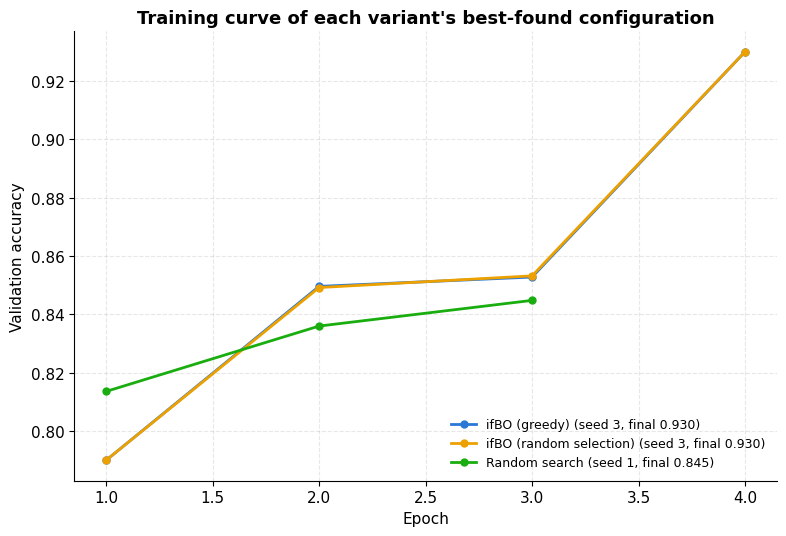

In [15]:
def best_trial_overall(variant_key: str) -> tuple[int, dict]:
    candidates = [
        (seed, t)
        for (v, seed), trials in raw_trials.items()
        if v == variant_key
        for t in trials
    ]
    seed, t = min(candidates, key=lambda st: st[1]["val_error"])
    return seed, t


fig, ax = plt.subplots(figsize=(8, 5.5))
for variant_key, variant_label in VARIANTS.items():
    seed, t = best_trial_overall(variant_key)
    epochs = [e["epoch"] for e in t["epoch_history"]]
    accs = [e["val_accuracy"] for e in t["epoch_history"]]
    ax.plot(
        epochs, accs, "o-", color=COLORS[variant_key], markersize=5, linewidth=2.0,
        label=f"{variant_label} (seed {seed}, final {1 - t['val_error']:.3f})",
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation accuracy")
ax.set_title("Training curve of each variant's best-found configuration", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9, frameon=False)
fig.tight_layout()
plt.show()


## Summary


In [16]:
summary = final_acc.agg(["mean", "std", "min", "max"]).T
summary["mean_n_trials"] = cost["n_trials"].mean()
summary["mean_wallclock_min"] = cost["total_wallclock_min"].mean()
summary


,mean,std,min,max,mean_n_trials,mean_wallclock_min
variant,,,,,,
ifBO (greedy),0.859977,0.045515,0.787500,0.9300,17.307692,25.007911
ifBO (random selection),0.876434,0.040901,0.790316,0.9300,15.000000,22.494523
Random search,0.831398,0.009256,0.821929,0.8448,15.000000,67.852046
